In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# HRDPS

In [2]:
hrdps = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m??d??.nc'))
print(len(hrdps))

363


In [3]:
combined = []
for file in hrdps:
    ds = xr.open_dataset(file)
    temp_data = ds["tair"]
    combined.append(temp_data.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean())

xr.concat(combined, dim="time_counter").to_dataset(name="tair").to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair.nc")

In [4]:
xr.concat(combined, dim="time_counter").shape

(2904, 266, 256)

In [5]:
ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair.nc")
print(ds_new)

<xarray.Dataset> Size: 791MB
Dimensions:       (time_counter: 2904, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2007-01-03 ... 2007-12-3...
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 791MB ...


In [6]:
print(ds_new.time_counter.values[0])
print(ds_new.time_counter.values[-1])

2007-01-03T00:00:00.000000000
2007-12-31T21:00:00.000000000


In [7]:
tair = ds_new["tair"]
X_new = tair.values.reshape(2904, 266 * 256)
X_new.shape

(2904, 68096)

In [8]:
# Check missing values
np.isnan(X_new).sum()

np.int64(0)

In [9]:
pca_hrdps = PCA(n_components=2)
PCs_hrdps = pca_hrdps.fit_transform(X_new)
PCs_hrdps.shape

(2904, 2)

In [10]:
pca_hrdps.components_

array([[ 1.4625788e-03,  1.4659741e-03,  1.4694406e-03, ...,
         5.2764621e-03,  5.4793470e-03,  5.0631091e-03],
       [-4.9181236e-03, -4.9180319e-03, -4.9191760e-03, ...,
        -2.5527241e-05,  1.1282774e-03, -4.2366888e-04]],
      shape=(2, 68096), dtype=float32)

Text(0, 0.5, 'rlat')

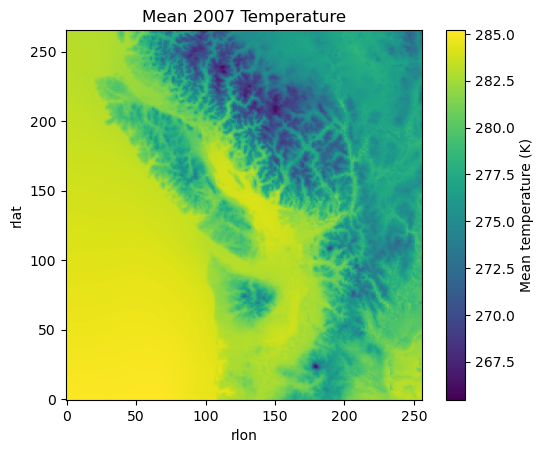

In [11]:
mean_2007 = pca_hrdps.mean_
mean_2007_map_hrdps = mean_2007.reshape(266, 256)
plt.imshow(mean_2007_map_hrdps, origin="lower")
plt.colorbar(label="Mean temperature (K)")
plt.title("Mean 2007 Temperature")
plt.xlabel("rlon")
plt.ylabel("rlat")

In [12]:
print(pca_hrdps.explained_variance_ratio_)
print(pca_hrdps.explained_variance_ratio_.sum())

[0.8855546 0.0388156]
0.9243702


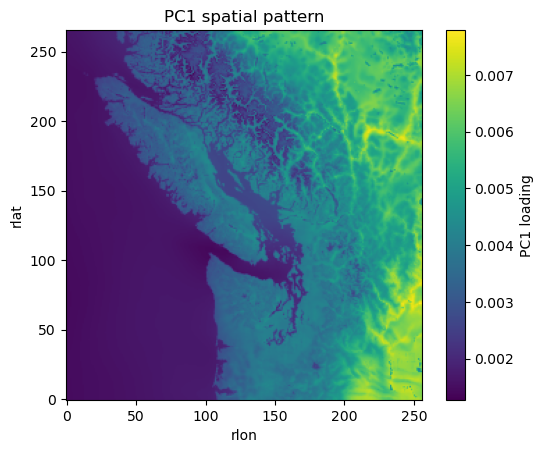

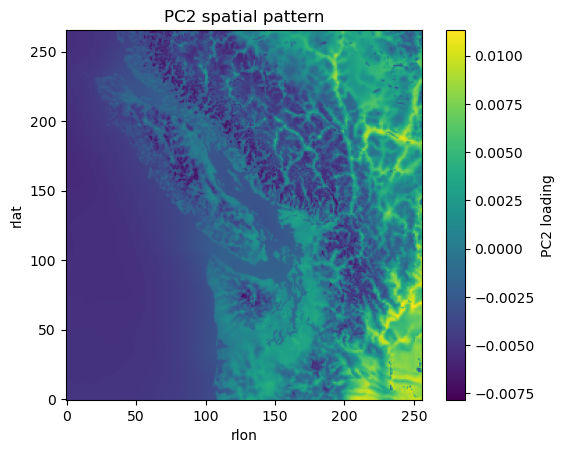

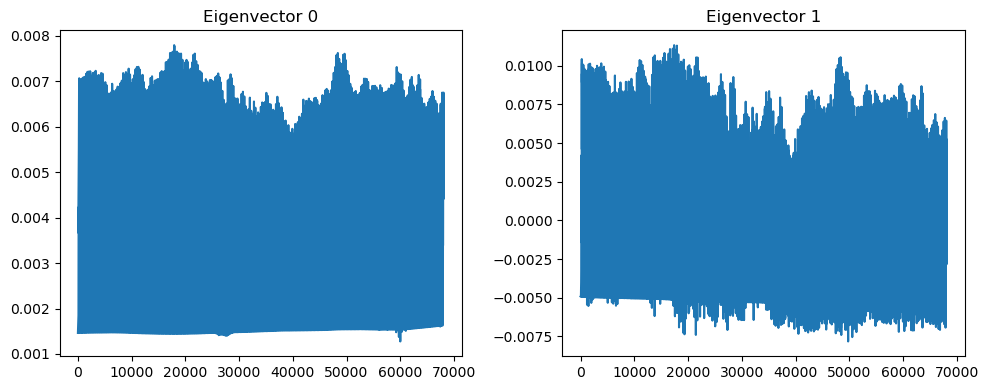

In [13]:
PC1_map_hrdps = pca_hrdps.components_[0].reshape(266, 256)
plt.imshow(PC1_map_hrdps, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map_hrdps = pca_hrdps.components_[1].reshape(266, 256)
plt.imshow(PC2_map_hrdps, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_hrdps.components_[0])
axes[0].set_title("Eigenvector 0")
axes[1].plot(pca_hrdps.components_[1])
axes[1].set_title("Eigenvector 1")
plt.tight_layout()
plt.show()

# CanRCM5

In [14]:
files = sorted(glob.glob('/results/forcing/CanRCM5/*2007*.nc'))
for file in files:
    if "tas" in xr.open_dataset(file).data_vars: #Near-Surface Air Temperature
        ds = xr.open_dataset(file) 
        break

ds_2007 = ds.sel(time=slice("2007-01-03", "2007-12-31")) #Select data from January 2007
print(ds_2007)

# Temperature data has shape: (time: 2904, rlat: 320, rlon: 360)
# This is 3 hourly temperature data for 2007

print(ds_2007["tas"].shape)

print(ds_2007["tas"].isel(time=0))

# Data is 2904 temperature maps, each of size 320x360 (latitude x longitude)


<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2904, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB ...
    lat           (rlat, rlon) float64 922kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 1GB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                  

In [15]:
tas = ds_2007["tas"]

In [16]:
X = tas.values.reshape(2904, 320 * 360) #Turns 3D array into 2D array of shape (2904, 115200) for PCA
X.shape
# Now in this matrix, each value is temperature at one grid cell at one time step


# Time steps (rows):
# Jan 3 00:00:00
# Jan 3 03:00:00
# ...
# Matrix:
#                 |Grid cell 1 | Grid cell 2 | ... | Grid cell 115200 |
# |Jan 3 00:00:00|
# |Jan 3 03:00:00|
# ...

# After reshaping, we have 115200 variables and 2904 number of observations.
# Since this is a lot of variables, PCA will be used for dimensionality reduction to find the main patterns of variability in the data.


(2904, 115200)

In [17]:
# Checking missing values before doing pca
np.isnan(X).sum()

np.int64(0)

In [18]:
X_mean = X.mean(axis=0)
X_centered = X - X_mean
print(X_centered.shape) 

(2904, 115200)


In [19]:
pca = PCA(n_components=2)
PCs = pca.fit_transform(X_centered)

In [20]:
pca.components_

array([[ 1.6927675e-05,  1.6512309e-05,  1.7309005e-05, ...,
         6.0981140e-04,  6.3474645e-04,  6.6163152e-04],
       [-8.8489667e-04, -8.7646133e-04, -8.6465548e-04, ...,
         7.6246564e-04,  8.0493913e-04,  8.5304957e-04]],
      shape=(2, 115200), dtype=float32)

[ 2.6261510e-05 -1.8537538e-04  1.7127255e-04 ... -1.4611447e-04
 -3.1081901e-04 -1.8083556e-04]


Text(0, 0.5, 'rlat')

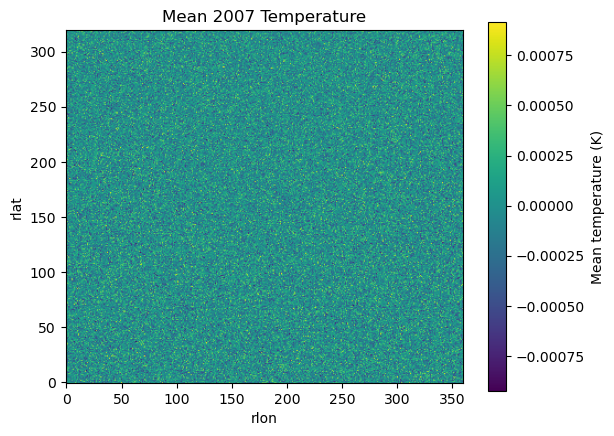

In [21]:
mean_2007 = pca.mean_
print(mean_2007)
mean_2007_map = mean_2007.reshape(320, 360)
plt.imshow(mean_2007_map, origin="lower")
plt.colorbar(label="Mean temperature (K)")
plt.title("Mean 2007 Temperature")
plt.xlabel("rlon")
plt.ylabel("rlat")

In [22]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.7490826 0.041534 ]
0.79061663


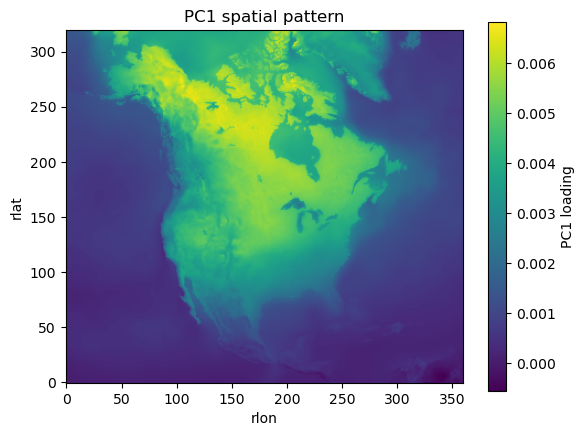

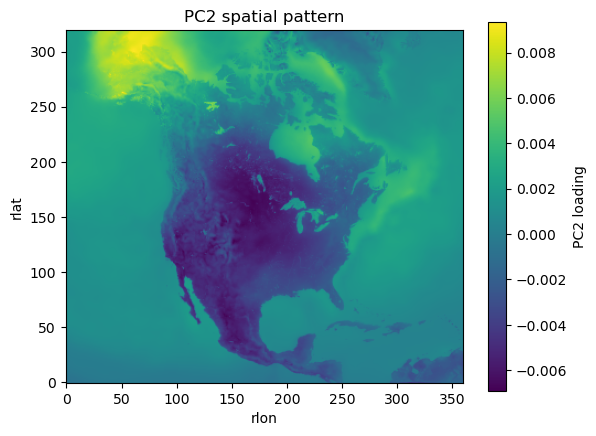

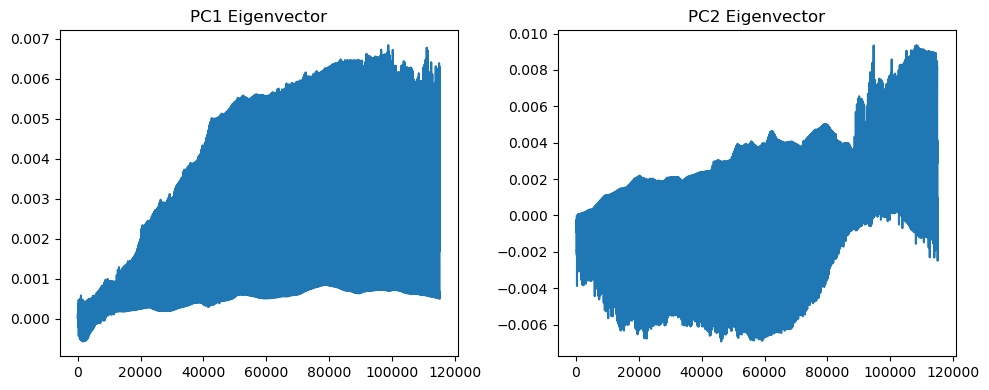

In [23]:
PC1_map = pca.components_[0].reshape(320, 360)
plt.imshow(PC1_map, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map = pca.components_[1].reshape(320, 360)
plt.imshow(PC2_map, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca.components_[0])
axes[0].set_title("PC1 Eigenvector")
axes[1].plot(pca.components_[1])
axes[1].set_title("PC2 Eigenvector")
plt.tight_layout()
plt.show()


# CanRCM5 Cutting to focus only on the area that is in HRDPS:

In [24]:
# Opening only the first file and extracting the latitude and longitude coordinates for the HRDPS data
ds0 = xr.open_dataset(hrdps[0])

lat_hr = ds0["nav_lat"]
lon_hr = ds0["nav_lon"]

In [25]:
ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair.nc")

# Adding the latitude and longitude coordinates to the new dataset
ds_new = ds_new.assign_coords(
    nav_lat=(("y", "x"), lat_hr.values),
    nav_lon=(("y", "x"), lon_hr.values)
)

ds_new.to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_tair_with_latlon.nc")

# ds_new now contains tair, nav_lat, and nav_lon variables

In [26]:
print(ds_new.time_counter[0].values)
print(ds_new.time_counter[-1].values)
print(len(ds_new.time_counter))

2007-01-03T00:00:00.000000000
2007-12-31T21:00:00.000000000
2904


In [27]:
corners = { "bottom_left": (float(lat_hr.isel(y=0, x=0)),float(lon_hr.isel(y=0, x=0))),
           "bottom_right": (float(lat_hr.isel(y=0, x=-1)),float(lon_hr.isel(y=0, x=-1))),
           "top_left": (float(lat_hr.isel(y=-1, x=0)),float(lon_hr.isel(y=-1, x=0))),
           "top_right": (float(lat_hr.isel(y=-1, x=-1)),float(lon_hr.isel(y=-1, x=-1)))}

for name, (lat, lon) in corners.items():
    print("name:", name)
    print("lat:", lat)
    print("lon:", lon)

name: bottom_left
lat: 45.61257553100586
lon: 232.6595001220703
name: bottom_right
lat: 46.535892486572266
lon: 240.79672241210938
name: top_left
lat: 51.41788864135742
lon: 230.60208129882812
name: top_right
lat: 52.4603157043457
lon: 239.75860595703125


In [28]:
hr_lats = []
hr_lons = []
for coord in corners.values():
    hr_lats.append(coord[0])
    hr_lons.append(coord[1])

lat_min = min(hr_lats)
lat_max = max(hr_lats)
lon_min = min(hr_lons)
lon_max = max(hr_lons)

print(lat_min, lat_max)
print(lon_min, lon_max)

45.61257553100586 52.4603157043457
230.60208129882812 240.79672241210938


In [29]:
lat_lr = ds_2007["lat"]
lon_lr = ds_2007["lon"]

In [30]:
# Converts longitudes from 0-360 to -180 to 180
lon_lr = ((lon_lr + 180) % 360) - 180

In [31]:
# Converts longitudes from 0-360 to -180 to 180
lon_min = ((lon_min + 180) % 360) - 180
lon_max = ((lon_max + 180) % 360) - 180

In [32]:
# Create a mask to identify which CanRCM5 grid cells fall within the HRDPS region
mask_lr = (
    (lat_lr >= lat_min) & (lat_lr <= lat_max) &
    (lon_lr >= lon_min) & (lon_lr <= lon_max)
)

print("Number of CanRCM5 cells in HRDPS region:", int(mask_lr.sum()))

Number of CanRCM5 cells in HRDPS region: 947


In [33]:
i_idx, j_idx = np.where(mask_lr.values) # Finds array indices where mask_lr is True

i_min, i_max = i_idx.min(), i_idx.max()
j_min, j_max = j_idx.min(), j_idx.max()

print(i_min, i_max, j_min, j_max) # These indices can be used to subset the CanRCM5 data to the HRDPS region for further analysis

162 200 79 117


In [34]:
ds_2007_cut = ds_2007.isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1))

print(ds_2007_cut)
print(ds_2007_cut["tas"].shape)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB 232.0 232.3 232.5 ... 239.3 239.6
    lat           (rlat, rlon) float64 12kB 43.66 43.74 43.82 ... 54.29 54.35
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 18MB 286.4 286.3 ... 260.6 260.8
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_mem

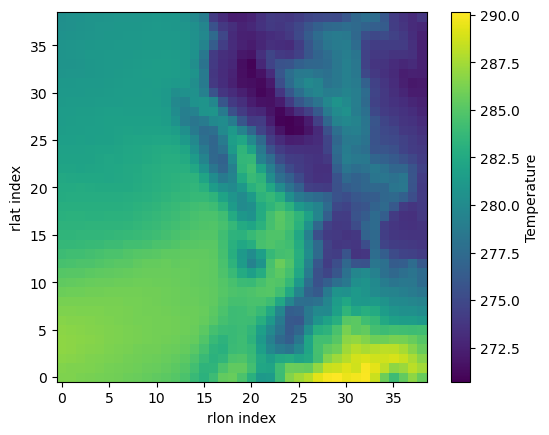

In [35]:
tas_cut = ds_2007_cut["tas"]
plt.imshow(tas_cut.isel(time=0), origin="lower")
plt.colorbar(label="Temperature")
plt.xlabel("rlon index")
plt.ylabel("rlat index")
plt.show()

In [36]:
n_time = tas_cut.sizes["time"]
n_rlat = tas_cut.sizes["rlat"]
n_rlon = tas_cut.sizes["rlon"]

X_cut = tas_cut.values.reshape(n_time, n_rlat * n_rlon)

print(X_cut.shape)

(2904, 1521)


In [37]:
X_mean_cut = X_cut.mean(axis=0)
X_centered_cut = X_cut - X_mean_cut
print(X_centered_cut.shape) 

(2904, 1521)


In [38]:
pca_cut = PCA(n_components=2)
PCs_cut = pca_cut.fit_transform(X_centered_cut)

print(pca_cut.explained_variance_ratio_)
print(pca_cut.explained_variance_ratio_.sum())

[0.86977005 0.03778262]
0.90755266


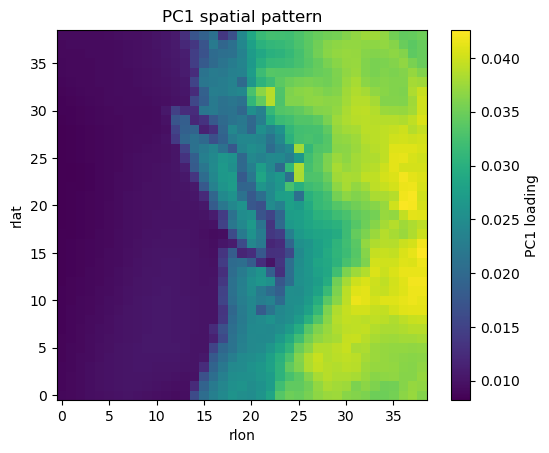

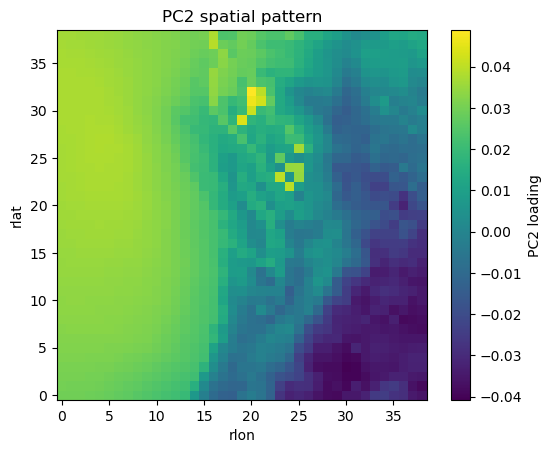

In [39]:
PC1_cut_map = pca_cut.components_[0].reshape(n_rlat, n_rlon)
plt.imshow(PC1_cut_map, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_cut_map = pca_cut.components_[1].reshape(n_rlat, n_rlon)
plt.imshow(PC2_cut_map, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

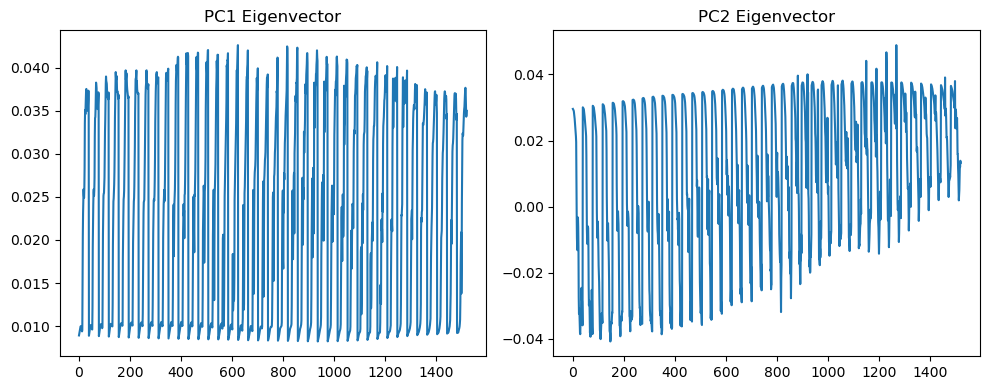

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_cut.components_[0])
axes[0].set_title("PC1 Eigenvector")
axes[1].plot(pca_cut.components_[1])
axes[1].set_title("PC2 Eigenvector")
plt.tight_layout()
plt.show()

## Checking correlation

In [41]:
lr_scores = PCs_cut[:, :2]   
hr_scores = PCs_hrdps[:, :2] 

corr_matrix = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        corr_matrix[i, j] = np.corrcoef(lr_scores[:, i], hr_scores[:, j])[0, 1]

corr_df = pd.DataFrame(
    corr_matrix,
    index=["CanRCM_PC1", "CanRCM_PC2"],
    columns=["HRDPS_PC1", "HRDPS_PC2"]
)

print(corr_df)

            HRDPS_PC1  HRDPS_PC2
CanRCM_PC1   0.961008  -0.061655
CanRCM_PC2   0.011762  -0.879973


In [42]:
abs_corr_df = corr_df.abs()
print(abs_corr_df)

            HRDPS_PC1  HRDPS_PC2
CanRCM_PC1   0.961008   0.061655
CanRCM_PC2   0.011762   0.879973


In [43]:
print(ds_2007_cut.time.values[:10])
print(ds_new.time_counter.values[:10])

print(ds_2007_cut.time.values[-10:])
print(ds_new.time_counter.values[-10:])

[cftime.DatetimeNoLeap(2007, 1, 3, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 3, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 6, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 15, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 18, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 21, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 4, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 4, 3, 0, 0, 0, has_year_zero=True)]
['2007-01-03T00:00:00.000000000' '2007-01-03T03:00:00.000000000'
 '2007-01-03T06:00:00.000000000' '2007-01-03T09:00:00.000000000'
 '2007-01-03T12:00:00.000000000' '2007-01-03T15:00:00.000000000'
 '2007-01-03T18:00:00.000000000' '2007-01-03T21:00:00.000000000'
 '2007-01-04T00:00:00.000000000' '2007-01-04T03:00:00.000000000']

In [44]:
pc_df = pd.DataFrame({
    "CanRCM_PC1": lr_scores[:, 0],
    "CanRCM_PC2": lr_scores[:, 1],
    "HRDPS_PC1": hr_scores[:, 0],
    "HRDPS_PC2": hr_scores[:, 1]
})

pairs = [("CanRCM_PC1", "HRDPS_PC1"),("CanRCM_PC2", "HRDPS_PC2")]

for lr_name, hr_name in pairs:
    print(lr_name, hr_name)
    for lag in range(-3, 4):
        corr = pc_df[lr_name].corr(pc_df[hr_name].shift(lag))
        print("Lag",lag,":",corr)

CanRCM_PC1 HRDPS_PC1
Lag -3 : 0.781934724466763
Lag -2 : 0.8180349822784805
Lag -1 : 0.8879879539305311
Lag 0 : 0.9610083571475506
Lag 1 : 0.9893953050048997
Lag 2 : 0.946977949414248
Lag 3 : 0.8689335974206022
CanRCM_PC2 HRDPS_PC2
Lag -3 : -0.6144660957962907
Lag -2 : -0.6714416663269924
Lag -1 : -0.7762660230659307
Lag 0 : -0.8799726084185366
Lag 1 : -0.9140346997305429
Lag 2 : -0.8426846431607767
Lag 3 : -0.7167614416312514


Lag 0 correlation is high for both LR_PC1 vs HR_PC1 and LR_PC2 vs HR_PC2. Lag 0 correlation represents the correlation between CanRCM5 and HRDPS at the exact same moment in time. Since it is high, data series is highly correlated.

## Can do MLR

In [45]:
lr_scores = PCs_cut[:, :2]   
hr_scores = PCs_hrdps[:, :2] 

In [46]:
time = pd.to_datetime([str(t) for t in ds_2007_cut.time.values])

In [47]:
pc_df = pd.DataFrame({
    "time": time,
    "CanRCM_PC1": lr_scores[:, 0],
    "CanRCM_PC2": lr_scores[:, 1],
    "HRDPS_PC1": hr_scores[:, 0],
    "HRDPS_PC2": hr_scores[:, 1]
})

In [48]:
print(pc_df.head())
print(pc_df.tail())

                 time  CanRCM_PC1  CanRCM_PC2    HRDPS_PC1   HRDPS_PC2
0 2007-01-03 00:00:00   23.661219  -24.216208  -222.870941  202.341614
1 2007-01-03 03:00:00   -7.355029  -29.846796  -432.275391  201.681824
2 2007-01-03 06:00:00  -43.789402  -26.797354  -612.413269  164.014664
3 2007-01-03 09:00:00  -75.242676  -18.878996  -759.536011  121.566971
4 2007-01-03 12:00:00 -109.640297   -7.706934 -1050.332031   -4.119760
                    time  CanRCM_PC1  CanRCM_PC2    HRDPS_PC1   HRDPS_PC2
2899 2007-12-31 09:00:00 -354.170105  -11.585293 -2150.188477  219.100143
2900 2007-12-31 12:00:00 -398.795319  -14.379659 -2519.353516   40.684059
2901 2007-12-31 15:00:00 -446.085938  -14.343934 -2803.344971    2.121764
2902 2007-12-31 18:00:00 -470.750916   -5.876247 -2171.489746  139.116837
2903 2007-12-31 21:00:00 -353.911804  -20.046591 -1695.791870  199.893570


In [49]:
train_df = pc_df[pc_df["time"] < "2007-10-01"]
test_df = pc_df[pc_df["time"] >= "2007-10-01"]
# Training 9 months and Testing 3 months

In [50]:
X_train = train_df[["CanRCM_PC1", "CanRCM_PC2"]].values
X_test = test_df[["CanRCM_PC1", "CanRCM_PC2"]].values
Y_train = train_df[["HRDPS_PC1", "HRDPS_PC2"]].values
Y_test = test_df[["HRDPS_PC1", "HRDPS_PC2"]].values

In [51]:
print(X_train)

[[ 23.661219  -24.216208 ]
 [ -7.3550286 -29.846796 ]
 [-43.789402  -26.797354 ]
 ...
 [ -4.10083    78.904655 ]
 [ 16.13417    64.95274  ]
 [ 48.77888    49.59518  ]]


In [52]:
mlr = LinearRegression()
mlr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
mlr.coef_

array([[ 6.2519875 ,  0.60980463],
       [-0.10004757, -5.821504  ]], dtype=float32)

In [54]:
mlr.intercept_

array([33.788116,  6.139511], dtype=float32)

In [55]:
Y_pred = mlr.predict(X_test)

In [56]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
adj_r2 = 1 - (1 - r2) * (len(Y_test) - 1) / (len(Y_test) - 2 - 1)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Adjusted R-squared:", adj_r2)

Mean Squared Error: 93401.734375
Mean Absolute Error: 224.55604553222656
R-squared: 0.7244518995285034
Adjusted R-squared: 0.7237000629651433


# Plots of PC scores

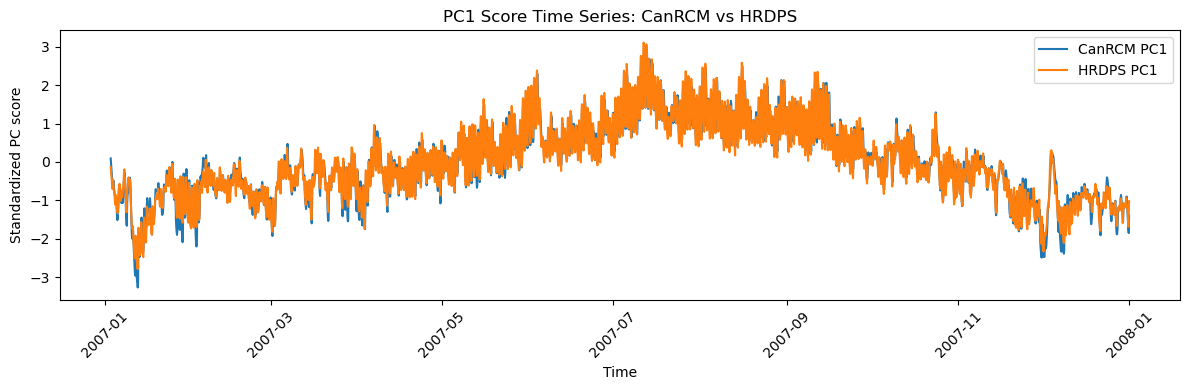

In [57]:
pc_df["CanRCM_PC1_std"] = (pc_df["CanRCM_PC1"] - pc_df["CanRCM_PC1"].mean()) / pc_df["CanRCM_PC1"].std()
pc_df["HRDPS_PC1_std"] = (pc_df["HRDPS_PC1"] - pc_df["HRDPS_PC1"].mean()) / pc_df["HRDPS_PC1"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_df["time"], pc_df["CanRCM_PC1_std"], label="CanRCM PC1")
plt.plot(pc_df["time"], pc_df["HRDPS_PC1_std"], label="HRDPS PC1")
plt.title("PC1 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

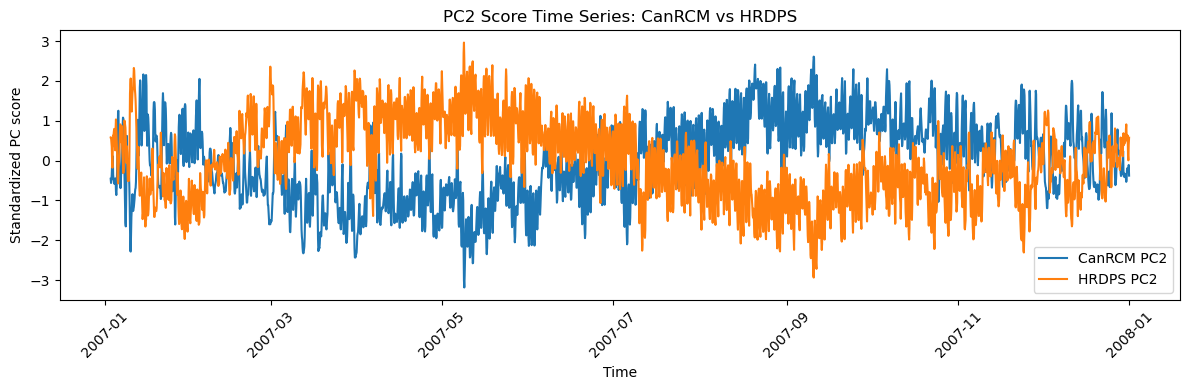

In [58]:
pc_df["CanRCM_PC2_std"] = (pc_df["CanRCM_PC2"] - pc_df["CanRCM_PC2"].mean()) / pc_df["CanRCM_PC2"].std()
pc_df["HRDPS_PC2_std"] = (pc_df["HRDPS_PC2"] - pc_df["HRDPS_PC2"].mean()) / pc_df["HRDPS_PC2"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_df["time"], pc_df["CanRCM_PC2_std"], label="CanRCM PC2")
plt.plot(pc_df["time"], pc_df["HRDPS_PC2_std"], label="HRDPS PC2")
plt.title("PC2 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()